# Imports

In [49]:
import numpy as np
from scipy.ndimage import maximum_filter
import cv2
from pathlib import Path
from matplotlib import pyplot as plt

# Median Filter

In [50]:
def median_filter(image, kernel_size):
    # # Create a copy of the image to avoid modifying the original
    # filtered_image = image.copy()
    
    # # Get the dimensions of the image
    # height, width = image.shape
    
    # # Calculate the padding needed for the kernel
    # pad = kernel_size // 2
    
    # # Pad the image with zeros
    # # mode='constant' with constant_values=0 will pad the image with zeros
    # padded_image = np.pad(image, pad_width=pad, mode='constant', constant_values=0)
    
    # # Apply the median filter
    # for i in range(height):
    #     for j in range(width):
    #         # Extract the neighborhood
    #         # The neighborhood is a square region of size kernel_size x kernel_size centered around the current pixel
    #         # center is the pixel at (i, j) in the original image, which corresponds to (i+pad, j+pad) in the padded image
    #         neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]
    #         # Replace the pixel with the median of the neighborhood
    #         filtered_image[i, j] = np.median(neighborhood)
    
    # Use OpenCV's built-in median filter for better performance and simplicity
    filtered_image = cv2.medianBlur(image, kernel_size)
    return filtered_image

# Canny's Algorithm

In [51]:
def canny_edge_detection(grayscale_image, low_threshold=100, high_threshold=200):

    edges = cv2.Canny(grayscale_image, low_threshold, high_threshold)
    return edges

# Region of interest

In [52]:
def region_of_interest(image, vertices, color=(255, 255, 255)):
    # Create a mask with the same dimensions as the image
    mask = np.zeros_like(image)
    
    # Fill the polygon defined by vertices with the specified color
    cv2.fillPoly(mask, [vertices], color)
    
    # Apply the mask to the image using bitwise AND
    masked_image = cv2.bitwise_and(image, mask)
    
    return masked_image

# Hough Tranform

In [53]:
def hough_transform(edges, rho_resolution=1, theta_resolution=np.pi/180):
    height, width = edges.shape

    # Maximum possible rho (image diagonal)
    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))
    rhos = np.arange(-diag_len, diag_len + 1, rho_resolution)

    # Theta values
    thetas = np.arange(0, np.pi, theta_resolution)

    # Accumulator array
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    # Indices of edge points
    y_idxs, x_idxs = np.nonzero(edges)

    # Precompute cos and sin of thetas for efficiency
    # for equation ρ = x * cos(θ) + y * sin(θ)
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    # Vectorized computation of ρ for all θ for each edge point
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        # Compute ρ for all θ at once using vectorized operations
        rho_vals = x * cos_t + y * sin_t
        # Convert ρ values to corresponding indices in the accumulator
        # Since ρ can be negative, we shift it by diag_len to ensure all indices are positive
        # rho_resolution is used to scale the ρ values to the correct index in the accumulator
        rho_idxs = np.round((rho_vals + diag_len) / rho_resolution).astype(int)
        accumulator[rho_idxs, np.arange(len(thetas))] += 1

    return accumulator, rhos, thetas

# Finding peaks

In [54]:
def find_hough_peaks(accumulator, num_peaks=5, threshold=50, neighborhood_size=5):
    
    # Apply maximum filter to find local maxima
    local_max = maximum_filter(accumulator, size=neighborhood_size)
    
    # Keep only points that are equal to the local maximum
    detected_peaks = (accumulator == local_max)
    
    # Apply threshold
    detected_peaks &= (accumulator > threshold)
    
    # Get coordinates of peaks
    peak_coords = np.argwhere(detected_peaks)
    
    # Sort peaks by accumulator value (descending)
    peak_values = [accumulator[r, t] for r, t in peak_coords]
    sorted_indices = np.argsort(peak_values)[::-1]
    
    # Keep only the strongest peaks
    peaks = []
    # [:num_peaks] to get the top num_peaks peaks
    for idx in sorted_indices[:num_peaks]:
        rho_idx, theta_idx = peak_coords[idx]
        peaks.append((rho_idx, theta_idx))
    
    return peaks

# Drawing lines

In [55]:
def draw_lines(image, peaks, rhos, thetas):
    for rho_idx, theta_idx in peaks:
        rho = rhos[rho_idx]
        theta = thetas[theta_idx]
        # Calculate the line parameters (a, b) for the line equation ax + by = rho
        a = np.cos(theta)
        b = np.sin(theta)
        # x0 and y0 are the coordinates of the point on the line closest to the origin (0, 0)
        x0 = a * rho
        y0 = b * rho
        # Calculate the start and end points of the line segment accurately based on the line parameters
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        # Draw the line on the image
        cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

In [56]:
def plot_accumulator(accumulator, rhos, thetas):
    plt.figure(figsize=(10, 8))
    
    # We use extent to map the array indices to actual Rho and Theta values
    # Extent format: [left, right, bottom, top]
    extent = [np.rad2deg(thetas[0]), np.rad2deg(thetas[-1]), rhos[-1], rhos[0]]
    
    # Display the accumulator
    # Use 'hot' or 'jet' colormap to make peaks stand out
    plt.imshow(accumulator, extent=extent, cmap='jet', aspect='auto')
    
    plt.title('Hough Accumulator (2D Parameter Space)')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Rho (pixels)')
    plt.colorbar(label='Number of Votes')
    
    plt.show()

In [57]:
def plots(image, median_filtered_image, edges, combined_image, masked_edges):
    #show original image vs original image with detected lines
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.subplot(1, 2, 2)
    plt.title('Combined Image with Detected Lines')
    plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Median Filtered Image')
    plt.imshow(median_filtered_image, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title('Canny Edges')
    plt.imshow(edges, cmap='gray')
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Masked Edges')
    plt.imshow(masked_edges, cmap='gray')
    plt.show()

In [58]:
def road_lane_detection(image_path, vertices = None):
    # Load the image
    image_path = Path(image_path)
    image = cv2.imread(str(image_path))
    
    # Convert to grayscale
    grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply median filter
    median_filtered_image = median_filter(grayscale_image, kernel_size=3)
    
    # Apply Canny edge detection
    edges = cv2.Canny(median_filtered_image, 150, 250)

    # Define the vertices of the region of interest (a polygon that focuses on the road)
    height, width = edges.shape
    if vertices is None:
        vertices = np.array([
            (0, height),          # Bottom-left corner
            (0, height // 2 + 100),
            (width // 2 - 50, height//2 -40),  
            (width, height)       # Bottom-right corner
        ], dtype=np.int32)
    # Apply the region of interest mask to the edges image
    masked_edges = region_of_interest(edges, vertices)

    hough_transform_accumulator, rhos, thetas = hough_transform(masked_edges)

    peaks = find_hough_peaks(hough_transform_accumulator, num_peaks=7, threshold=50, neighborhood_size=5)

    # Create a black image to draw the detected lines
    black_image = np.zeros_like(image)
    draw_lines(black_image, peaks, rhos, thetas)
    # Apply the region of interest mask to the black image with detected lines
    masked_black_image = region_of_interest(black_image, vertices, color=(0, 255, 0))

    # Combine the original image with the detected lines
    combined_image = cv2.addWeighted(image, 0.8, masked_black_image, 1, 0)
    
    # Draw detected lines on the black image
    draw_lines(masked_black_image, peaks, rhos, thetas)

    plots(image, median_filtered_image, edges, combined_image, masked_edges)
    plot_accumulator(hough_transform_accumulator, rhos, thetas)


# Main

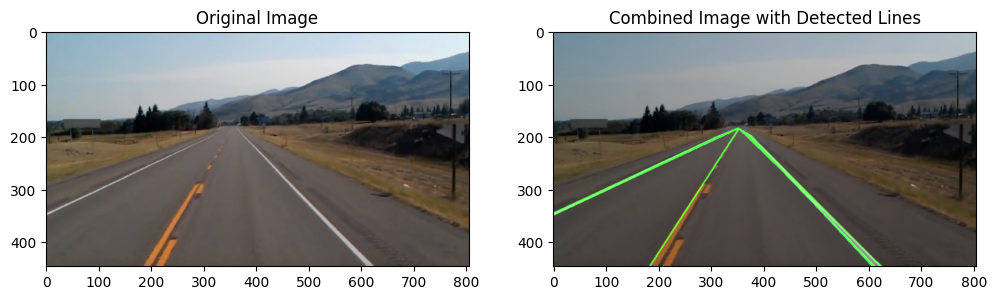

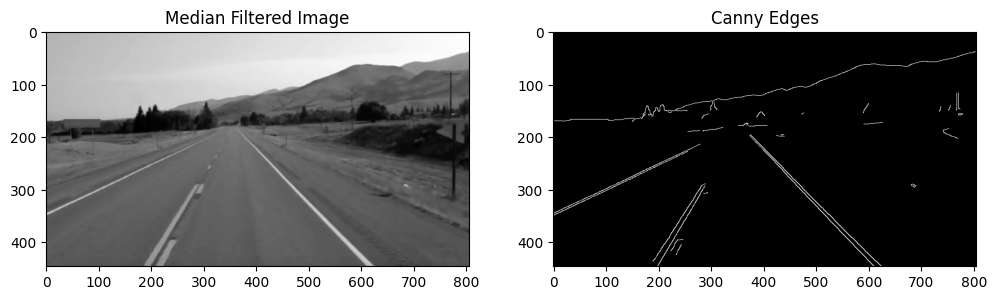

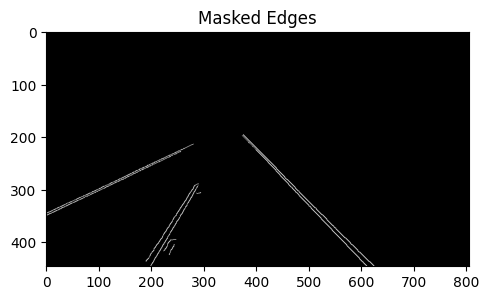

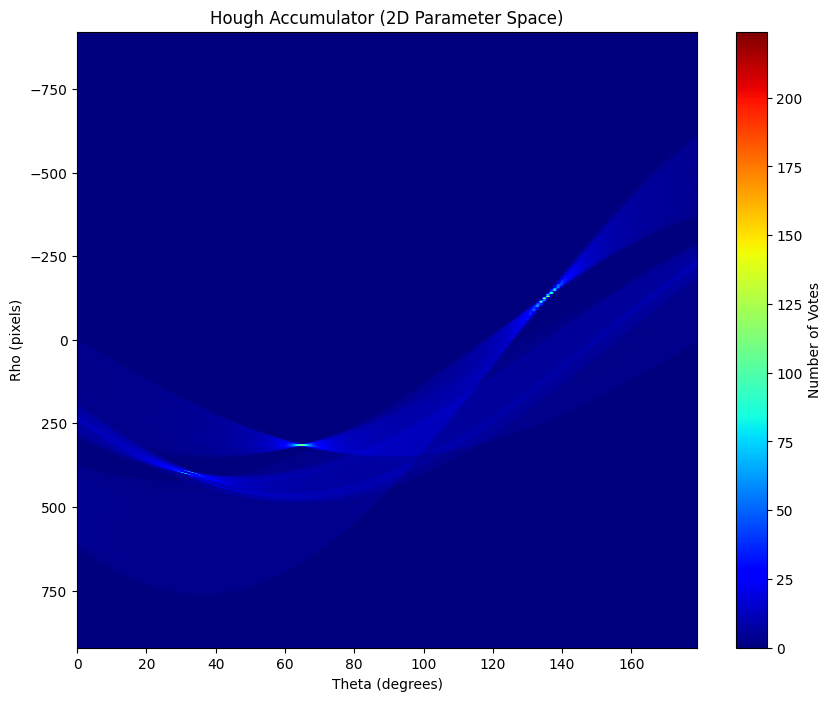

In [59]:


image_path =  Path('part2-images/part2-image.png')
road_lane_detection(str(image_path))

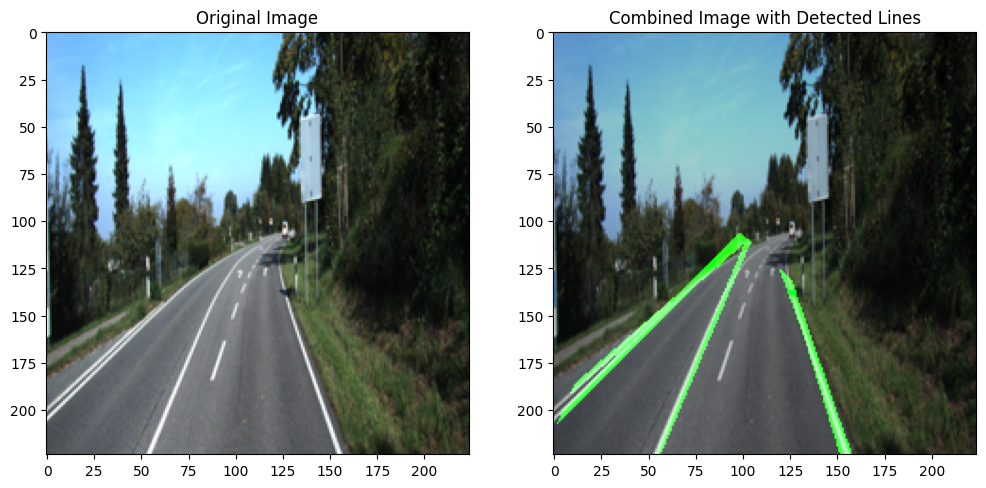

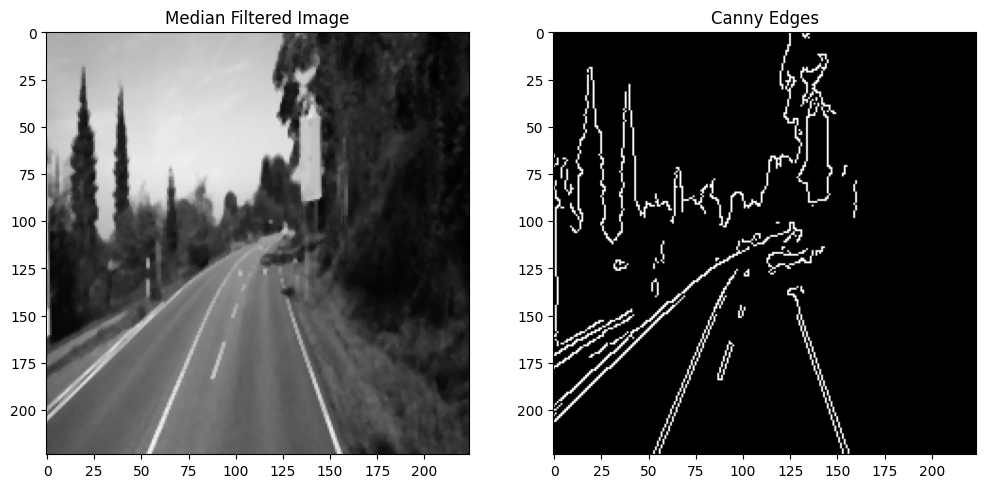

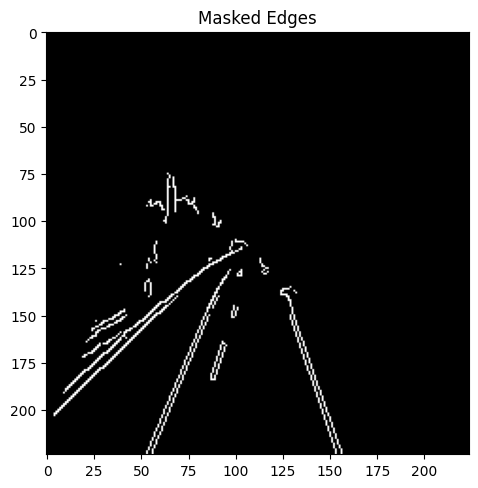

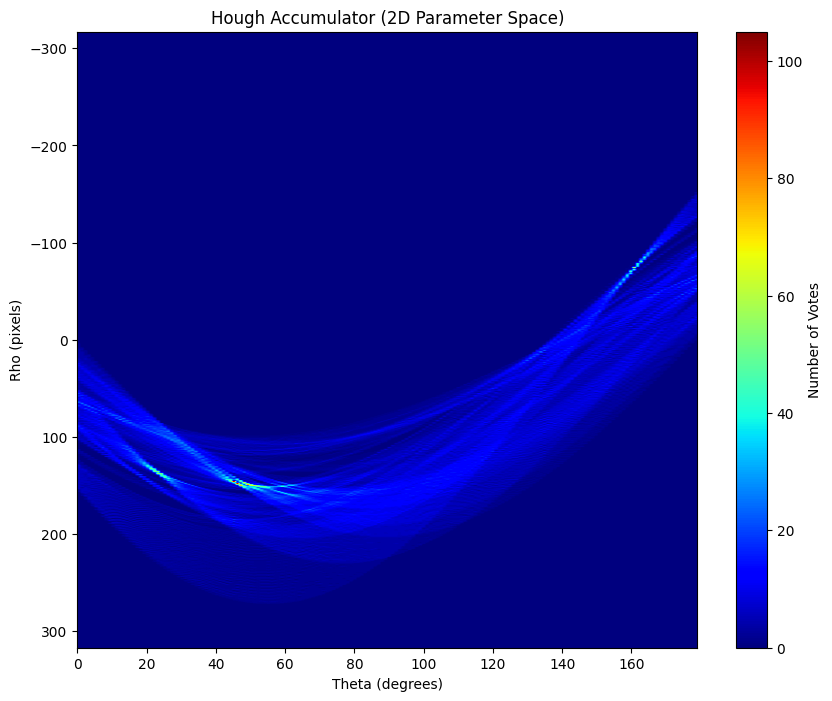

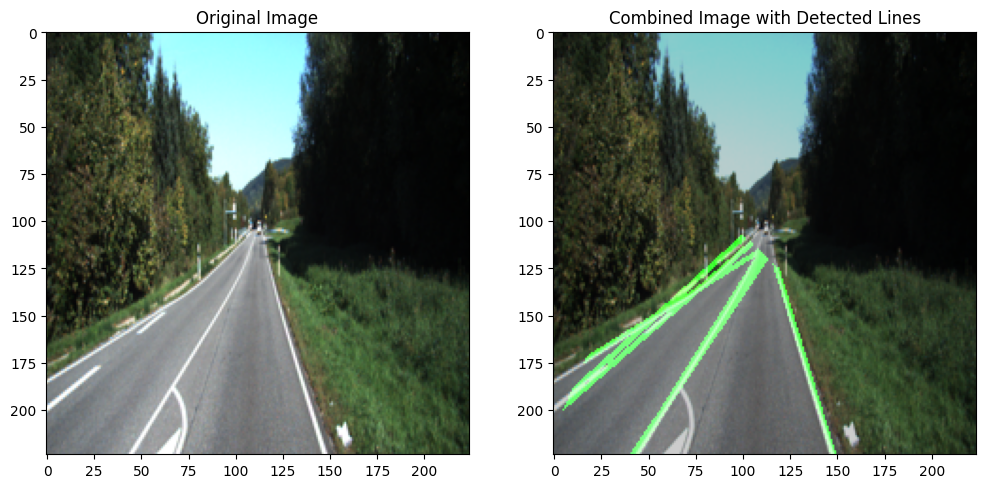

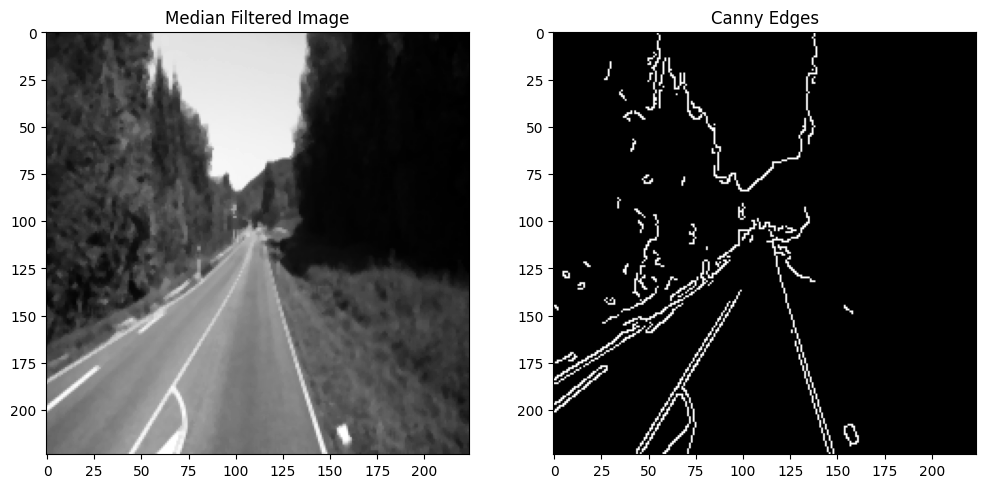

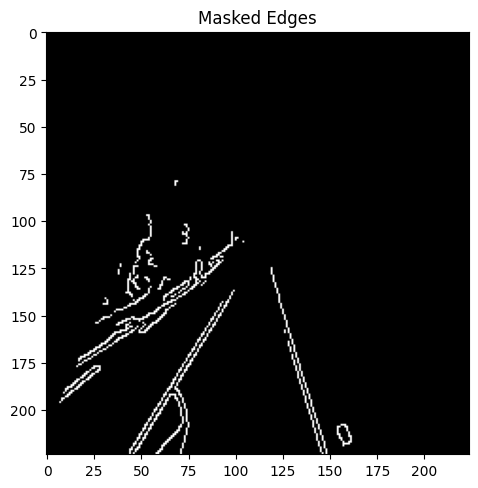

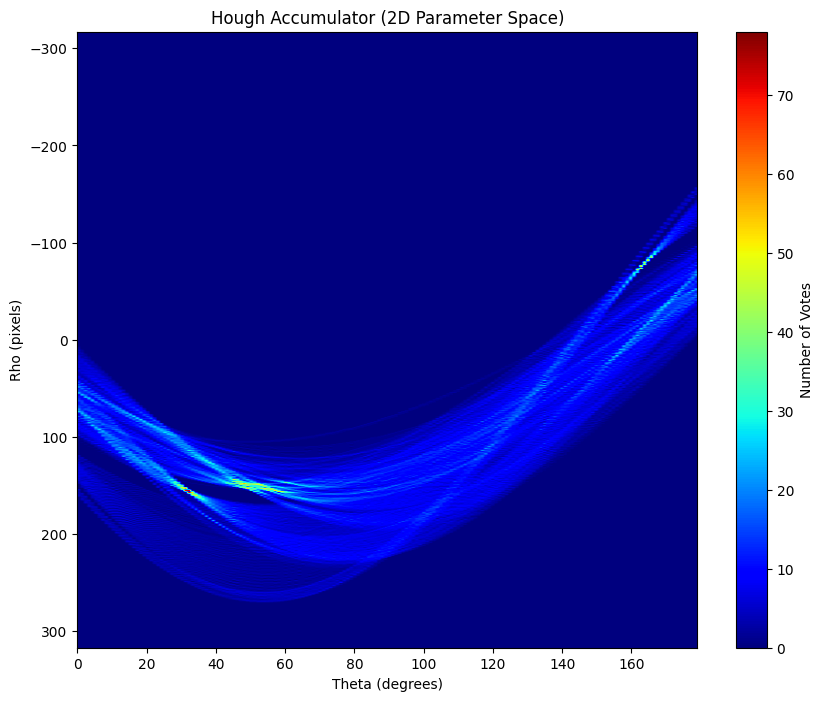

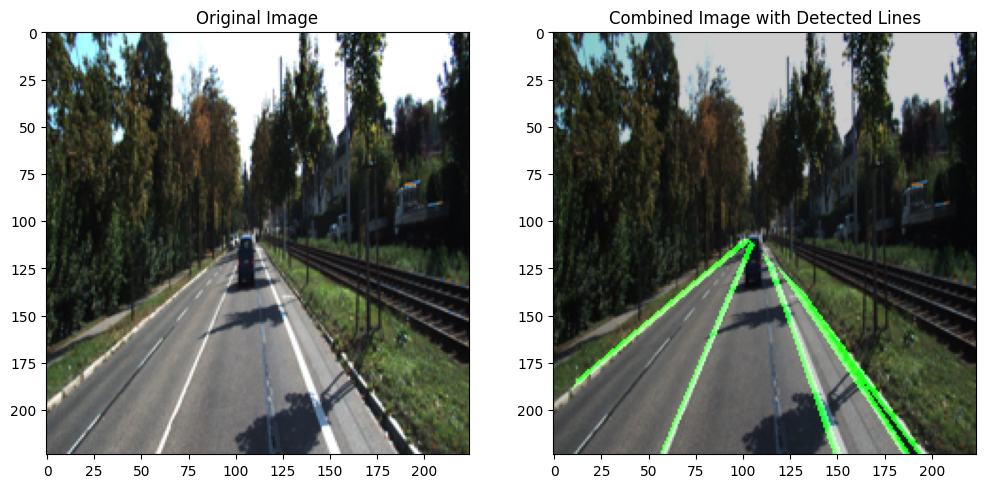

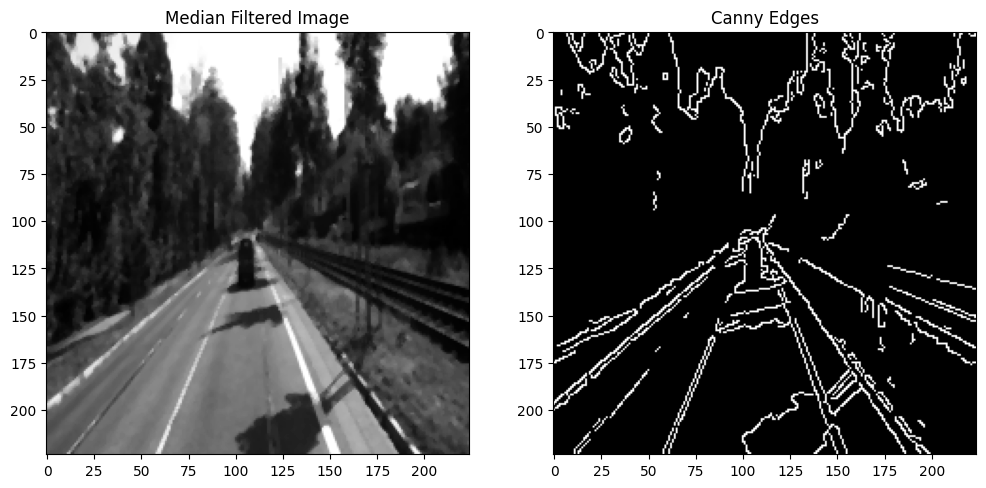

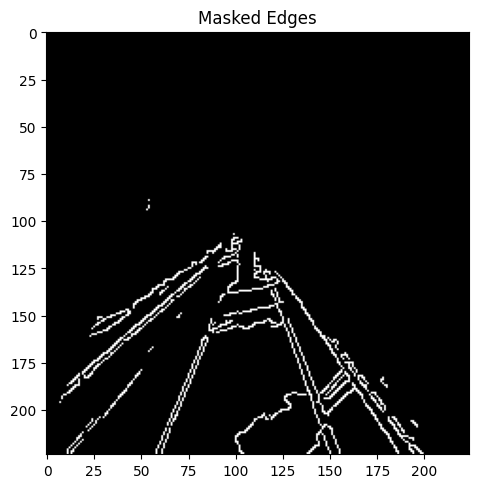

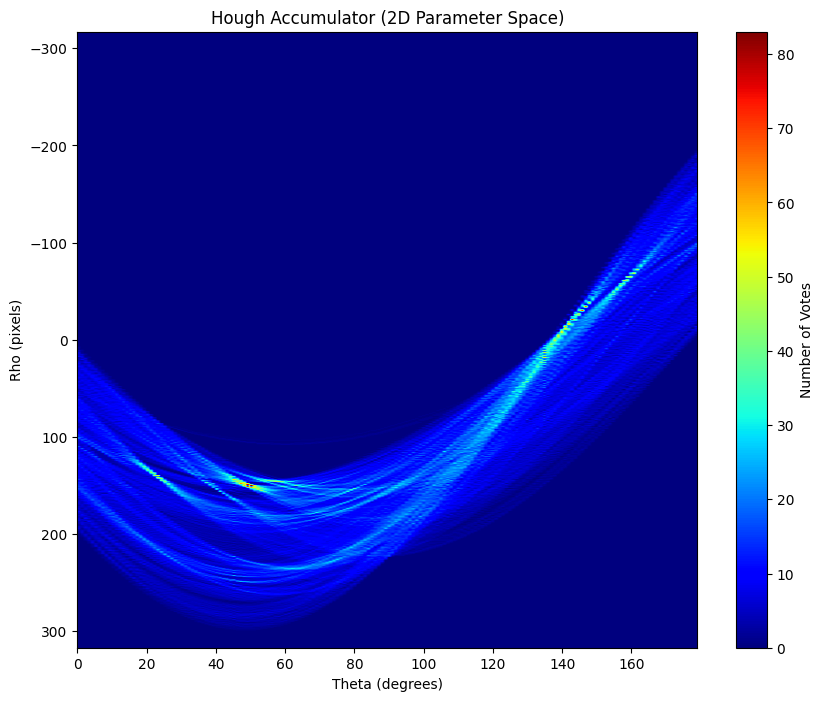

In [60]:


image_paths = [
    Path('part2-images/part-2-test-image-1.png'),
    Path('part2-images/part-2-test-image-3.png'),
    Path('part2-images/part-2-test-image-2.png'),
]

for image_path in image_paths:
    road_lane_detection(str(image_path))